In [ ]:
import os
os.getenv("GROQ_API_KEY")

In [21]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [22]:
model = "qwen/qwen3-32b"

In [23]:
from langchain_groq import ChatGroq

In [24]:
llm = ChatGroq(model_name = model)

In [25]:
llm.invoke("hi")

AIMessage(content='<think>\nOkay, the user just said "hi". That\'s a greeting. I should respond politely. Let me check the guidelines. I need to be friendly and offer assistance. Maybe say "Hello!" and ask how I can help. Keep it simple and open-ended. Make sure to use an emoji to keep the tone positive. Alright, that should work.\n</think>\n\nHello! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 9, 'total_tokens': 96, 'completion_time': 0.163624229, 'prompt_time': 0.00696716, 'queue_time': 0.045267118, 'total_time': 0.170591389}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--15728dd7-e869-40a8-a6cf-237d35fbf440-0', usage_metadata={'input_tokens': 9, 'output_tokens': 87, 'total_tokens': 96})

In [26]:
import operator
from typing import List
from langgraph.graph.message  import add_messages
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END,MessagesState
#from typing import TypedDict as MessageState

In [27]:
def call_model(state:MessagesState):
    message = state["messages"]
   # question = HumanMessage(message)
    print(f"This is my current message: {message}")
    response = llm.invoke(message)
    return {"messages":[response]}

In [28]:
state={"messages":["hi from message1"]}
call_model(state)

This is my current message: ['hi from message1']


{'messages': [AIMessage(content='<think>\nOkay, the user said "hi from message1". Let me see. They might just be testing or starting a conversation. I should respond in a friendly and open way. Maybe acknowledge their message and ask how I can help them today. Keep it simple and inviting. Let me make sure there\'s no hidden request here. Nope, seems like a straightforward greeting. Alright, reply with a cheerful tone.\n</think>\n\nHello! 😊 How can I assist you today? Let me know if you have any questions or need help with something specific!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 12, 'total_tokens': 124, 'completion_time': 0.216875779, 'prompt_time': 0.011406581, 'queue_time': 0.045885438, 'total_time': 0.22828236}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--94c4c474-1250-4efc-b5b2-97b323602888-0', usage_metadata={'

In [29]:
workflow = StateGraph(MessagesState)

In [30]:
workflow.add_node("mybot", call_model)

In [31]:
workflow.add_edge(START, "mybot")

In [32]:
workflow.add_edge("mybot",END)

In [33]:
app= workflow.compile()

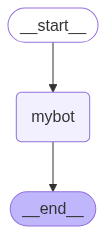

In [34]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [35]:
input = {"messages":["hi from message1"]}

In [36]:
app.invoke(input)

This is my current message: [HumanMessage(content='hi from message1', additional_kwargs={}, response_metadata={}, id='fc54e840-30fb-461d-ac82-e285f9046d13')]


{'messages': [HumanMessage(content='hi from message1', additional_kwargs={}, response_metadata={}, id='fc54e840-30fb-461d-ac82-e285f9046d13'),
  AIMessage(content='<think>\nOkay, the user said "hi from message1". Let me see. They might be testing if I\'m paying attention to the message numbers or just starting a conversation.\n\nI should acknowledge their message and ask how I can help. Maybe they have a specific question or need assistance with something. Keeping the response friendly and open-ended seems best. Let me make sure to invite them to ask anything they need.\n</think>\n\nHello! How can I assist you today? Feel free to ask any questions or share anything you\'d like help with. 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 12, 'total_tokens': 124, 'completion_time': 0.222258599, 'prompt_time': 0.011520519, 'queue_time': 0.045102141, 'total_time': 0.233779118}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5

In [37]:
for output in app.stream(input):
    for key, value in output.items():
        print(f"{key}: {value}")
        print("_______")
        print(value)
        print("\n")

This is my current message: [HumanMessage(content='hi from message1', additional_kwargs={}, response_metadata={}, id='66913d1d-3405-4a50-a710-f71e253bc70c')]
mybot: {'messages': [AIMessage(content='<think>\nOkay, the user said "hi from message1". I need to respond appropriately. Since this is the first message in a potential conversation, I should greet them back and ask how I can assist. I\'ll keep it friendly and open-ended.\n\nFirst, acknowledge their greeting. Then, offer help. Maybe something like, "Hello! How can I assist you today?" That\'s straightforward and invites them to ask for help with whatever they need.\n\nWait, but the user might have more context if there\'s a follow-up. But since this is the first message, I should just respond as if it\'s a new conversation. No need to assume previous messages unless specified. So the response should be welcoming and ready to help.\n</think>\n\nHello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usa